| Technological Institute of the Philippines | Quezon City - Computer Engineering |
|-------------------------------------------|------------------------------------|
| **Course Code:** | CPE 027 |
| **Code Title:** | Digital Signal Processing and Applications |
| **1st Semester** | AY 2026-2027 |
| **ACTIVITY NO. 8** | **Fundamental Discrete Fourier Transform in Python** |
| **Name:** | Pascual, Ken Leonard <br>|
| **Section:** | CPE41S2 |
| **Date Performed:** | 4 September 2026 |
| **Date Submitted:** | 4 September 2026 |
| **Instructor:** | Engr. Jimlord M. Quejado |

## 1. Objectives

This activity aims to introduce the Fourier transform process by demonstrating with the programmatic processing of both arbitrarily generated signals and collected data.

## 2. Intended Learning Outcomes (ILOs)
After completion of this activity, the students should be able to:

1. Develop a program capable of frequency domain using ideal DFT.

## 3. Discussion


The Discrete Fourier Transform (DFT) is one of the most important tools in Digital Signal Processing. This chapter discusses three common ways it is used. First, the DFT can calculate a signal's frequency spectrum. This is a direct examination of information encoded in the frequency, phase, and amplitude of the component sinusoids. For example, human speech and hearing use signals with this type of encoding. Second, the DFT can find a system's frequency response from the system's impulse response, and vice versa. This allows systems to be analyzed in the frequency domain, just as convolution allows systems to be analyzed in the time domain. Third, the DFT can be used as an intermediate step in more elaborate signal processing techniques. The classic example of this is FFT convolution, an algorithm for convolving signals that is hundreds of times faster than conventional methods.

This procedure is formalized in the analysis equation, the mathematical way to calculate the frequency domain from the time domain:

$$
\text{Re } X[k] = \sum_{i=0}^{N-1} x[i] \cos\left(\frac{2\pi k i}{N}\right)
$$

$$
\text{Im } X[k] = -\sum_{i=0}^{N-1} x[i] \sin\left(\frac{2\pi k i}{N}\right)
$$

In words, each sample in the frequency domain is found by multiplying the time domain signal by the sine or cosine wave being looked for, and adding the resulting points.

## 4. Resources
The activity will require the following software, tools and equipment:
* IDE or any online code editor

## 5. Directions:

#### 1. Create a composite signal consisting of six (6) different sinusoidal waves with frequencies of 20 Hz, 80 Hz, 200 Hz, 500 Hz, 800 Hz and 2000 Hz, with amplitudes of 10, 9, 11, 14, 7, 12 for each frequencies respectively, and phases of $\frac{\pi}{3}, \frac{\pi}{7}, \pi, \frac{2\pi}{3}, \frac{3\pi}{8}, \frac{\pi}{2}$, respectively. Plot its first 1 second.

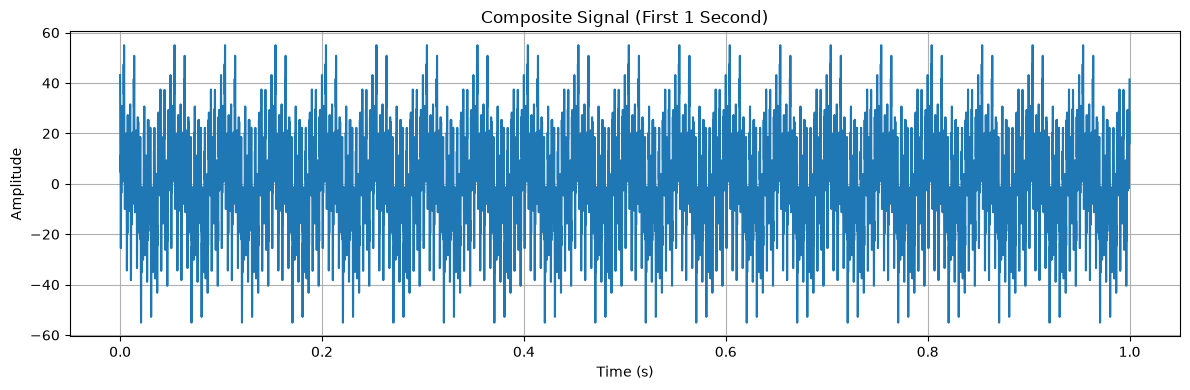

In [1]:
import numpy as np
import matplotlib.pyplot as plt

frequencies = np.array([20, 80, 200, 500, 800, 2000])
amplitudes = np.array([10, 9, 11, 14, 7, 12])
phases = np.array([
    np.pi / 3,
    np.pi / 7,
    np.pi,
    2 * np.pi / 3,
    3 * np.pi / 8,
    np.pi / 2
])

Fs_continuous = 20000  # high rate to approximate continuous signal
t = np.arange(0, 1, 1 / Fs_continuous)

x_continuous = np.zeros(len(t))
for i in range(len(frequencies)):
    x_continuous += amplitudes[i] * np.sin(2 * np.pi * frequencies[i] * t + phases[i])

plt.figure(figsize=(12, 4))
plt.plot(t, x_continuous)
plt.title('Composite Signal (First 1 Second)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.show()

A composite signal is constructed by summing six sinusoidal waves, each defined by a frequency, amplitude, and phase offset.  A very high sampling rate of 20,000 Hz is used to produce a near-continuous representation for plotting purposes.

The resulting waveform appears complex and irregular because it contains frequencies spanning two orders of magnitude (20 Hz to 2000 Hz). The plot shows the first 1 second of this composite signal in the time domain. While the individual sinusoids are straightforward, their superposition produces a signal whose frequency content is not visually obvious, which is precisely what the Fourier Transform is designed to reveal.

#### 2. Identify the sampling rate for proper sampling. Then, plot the sampled signal with n index for 1 second.

Highest frequency: 2000 Hz
Minimum sampling rate (Nyquist): 4000 Hz
Chosen sampling rate: 5000 Hz


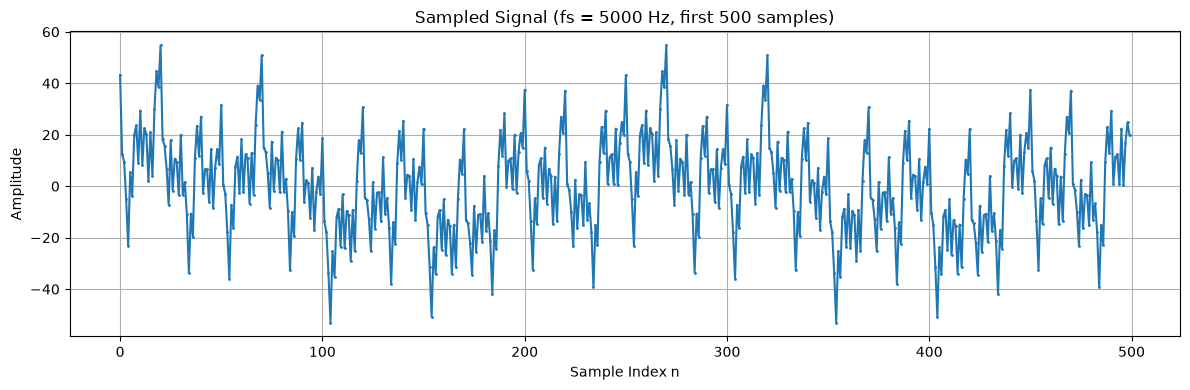

In [2]:
f_max = np.max(frequencies)
Fs_min = 2 * f_max  # Nyquist rate
print(f'Highest frequency: {f_max} Hz')
print(f'Minimum sampling rate (Nyquist): {Fs_min} Hz')

Fs = 5000  # above Nyquist (4000 Hz)
print(f'Chosen sampling rate: {Fs} Hz')

N = Fs  # number of samples in 1 second
n = np.arange(N)          # sample indices
t_sampled = n / Fs        # sampled time instants

# Build sampled signal
x = np.zeros(N)
for i in range(len(frequencies)):
    x += amplitudes[i] * np.sin(2 * np.pi * frequencies[i] * t_sampled + phases[i])

plt.figure(figsize=(12, 4))
plt.plot(n[:500], x[:500], marker='.', markersize=2)
plt.title(f'Sampled Signal (fs = {Fs} Hz, first 500 samples)')
plt.xlabel('Sample Index n')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.show()

The Nyquist-Shannon sampling theorem states that the sampling rate must be at least twice the highest frequency component to avoid aliasing. Here, the highest frequency is 2000 Hz, so the minimum sampling rate is 4000 Hz. A rate of $F_s = 5000$ Hz is chosen, which satisfies this requirement and yields $N = 5000$ samples for 1 second of signal.

The sample indices `n` range from 0 to 4999, and the corresponding time instants are $t = n / F_s$. The sampled signal `x` is reconstructed by summing the six sinusoidal components at these discrete time points. The plot displays the first 500 samples with markers, showing the composite waveform as a sequence of discrete points rather than a continuous curve. This is the discrete-time signal that the DFT will process.

#### 3. Now, perform Discrete Fourier Transform calculation using the **basis functions**. Plot its Re X[k] and Im X[k] values.

DFT completed in 12.28 seconds


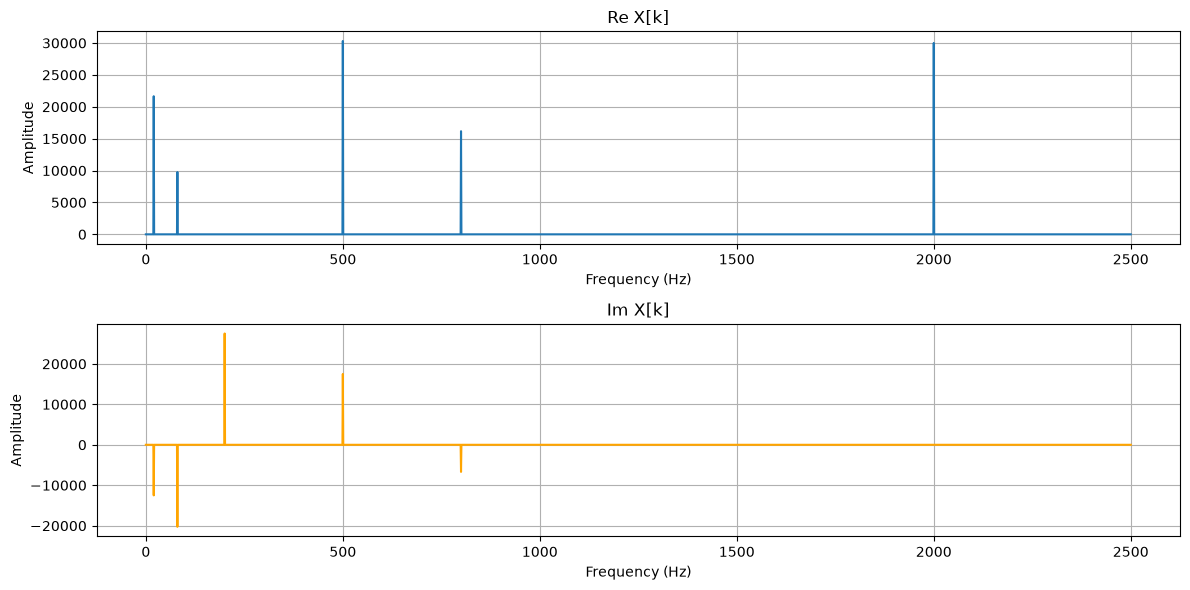

In [3]:
import time

# DFT using basis functions (for loops only — no FFT)
# Re X[k] = sum x[i] * cos(2*pi*k*i/N)
# Im X[k] = -sum x[i] * sin(2*pi*k*i/N)

K = N // 2 + 1  # only need first half for real signals
Re_X = np.zeros(K)
Im_X = np.zeros(K)

start = time.time()
for k in range(K):
    sum_re = 0.0
    sum_im = 0.0
    for i in range(N):
        angle = 2 * np.pi * k * i / N
        sum_re += x[i] * np.cos(angle)
        sum_im += x[i] * np.sin(angle)
    Re_X[k] = sum_re
    Im_X[k] = -sum_im
elapsed = time.time() - start
print(f'DFT completed in {elapsed:.2f} seconds')

freq_axis = np.arange(K) * Fs / N  # frequency bins in Hz

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))
ax1.plot(freq_axis, Re_X)
ax1.set_title('Re X[k]')
ax1.set_xlabel('Frequency (Hz)')
ax1.set_ylabel('Amplitude')
ax1.grid(True)
ax2.plot(freq_axis, Im_X, color='orange')
ax2.set_title('Im X[k]')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Amplitude')
ax2.grid(True)
plt.tight_layout()
plt.show()

The DFT is computed using nested `for` loops implementing the analysis equations aforementioned in the Discussion section.

The outer loop iterates over each frequency bin $k$ from $0$ to $N/2$, and the inner loop sums the product of the signal $x[i]$ with the cosine and sine basis functions at that frequency. Only the first half of the spectrum ($N/2 + 1$ bins) is computed because the signal is real-valued, making the second half a mirror image (conjugate symmetric).

The `time.time()` calls bracket the DFT to measure its execution time, highlighting the O(N^2) cost. The frequency axis is constructed as $k \cdot F_s / N$, mapping each bin index to its corresponding frequency in Hz. The plots show sharp peaks at the six expected frequencies (20, 80, 200, 500, 800, 2000 Hz), with the real part following cosine correlation and the imaginary part following sine correlation.

#### Formula for Magnitude and Phase:

$$
\text{Mag } X[k] = \sqrt{(\text{Re } X[k])^2 + (\text{Im } X[k])^2}
$$

$$
\text{Phase } X[k] = \arctan\left(\frac{\text{Im } X[k]}{\text{Re } X[k]}\right)
$$

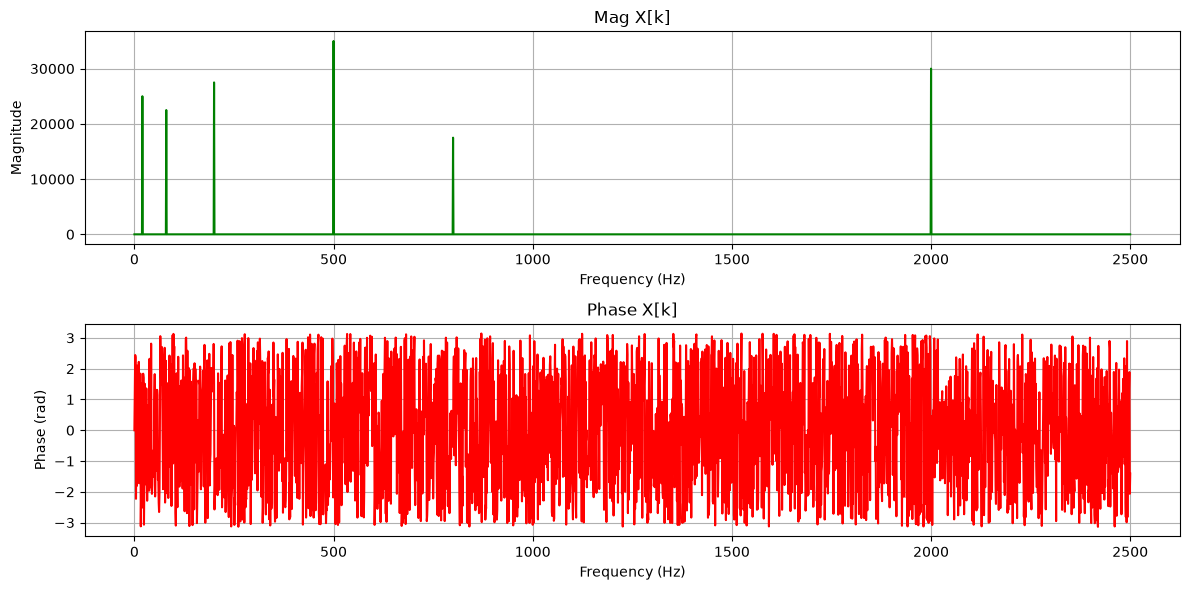

Detected frequency components (peak magnitude):
  20 Hz -> Mag = 25000.00, Phase = -0.5236 rad
  80 Hz -> Mag = 22500.00, Phase = -1.1220 rad
  200 Hz -> Mag = 27500.00, Phase = 1.5708 rad
  500 Hz -> Mag = 35000.00, Phase = 0.5236 rad
  800 Hz -> Mag = 17500.00, Phase = -0.3927 rad
  2000 Hz -> Mag = 30000.00, Phase = -0.0000 rad

Original amplitudes: [np.int64(10), np.int64(9), np.int64(11), np.int64(14), np.int64(7), np.int64(12)]
Original phases:     ['1.0472', '0.4488', '3.1416', '2.0944', '1.1781', '1.5708']


In [4]:
# Magnitude and Phase
# Mag X[k] = sqrt( Re X[k]^2 + Im X[k]^2 )
# Phase X[k] = arctan( Im X[k] / Re X[k] )

Mag_X = np.sqrt(Re_X**2 + Im_X**2)
Phase_X = np.arctan2(Im_X, Re_X)  # arctan2 handles division by zero

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))
ax1.plot(freq_axis, Mag_X, color='green')
ax1.set_title('Mag X[k]')
ax1.set_xlabel('Frequency (Hz)')
ax1.set_ylabel('Magnitude')
ax1.grid(True)
ax2.plot(freq_axis, Phase_X, color='red')
ax2.set_title('Phase X[k]')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Phase (rad)')
ax2.grid(True)
plt.tight_layout()
plt.show()

# Print detected peaks
print('Detected frequency components (peak magnitude):')
for i in range(len(frequencies)):
    k = int(frequencies[i] * N / Fs)
    print(f'  {frequencies[i]} Hz -> Mag = {Mag_X[k]:.2f}, Phase = {Phase_X[k]:.4f} rad')
print(f'\nOriginal amplitudes: {list(amplitudes)}')
print(f'Original phases:     {[f"{p:.4f}" for p in phases]}')

The magnitude spectrum `Mag X[k]` is computed as the Euclidean norm of the real and imaginary parts: $\sqrt{\text{Re}^2 + \text{Im}^2}$. This gives the strength of each frequency component regardless of phase. The phase spectrum `Phase X[k]` uses `arctan2(Im, Re)` to determine the angular offset of each sinusoidal component in radians. Using `arctan2` instead of plain `arctan` correctly handles all four quadrants and avoids division-by-zero errors.

The printed output verifies the DFT by mapping each target frequency bin to its detected magnitude and phase. The magnitude at each peak should match the original amplitude, and the phase should match the original phase offset, confirming that the DFT successfully decomposed the composite signal into its constituent sinusoids.

## 6. Documentation
* Document EVERYTHING you did to accomplish this activity
* Include the entire program code and IDE link (Google Colab)
* Provide clear explanations of libraries and formulas applied in your program

## 7. Summary and Conclusions

 

The manual implementation of the Discrete Fourier Transform using nested for loops has a **time complexity of O(N^2)**, where N is the number of samples. For N = 5000 samples, the algorithm performs roughly 25 million multiply-and-add operations for each of the N/2 frequency bins. This makes the naive DFT computationally expensive and impractical for large datasets or real-time applications.

This activity demonstrates how inefficient the direct DFT computation is compared to using optimized libraries.

In practice, not a lot of people would implement DFT with brute-force nested loops. This activity helps demonstrate what the DFT actually computes at its core by correlating the signal with each sinusoidal basis function.

Despite the slowness, the manual DFT correctly identifies all six frequency components (20, 80, 200, 500, 800, 2000 Hz) with their respective amplitudes and phases, confirming that the frequency-domain representation faithfully encodes the original signal.

In other words, the tasks done in this activity checks the signal against every possible frequency one by one, then measures how strongly each frequency shows up and how it's timed, then compares those measurements to the frequencies planted in the signal. 

## 8. Learning and Challenges

In this activity, I was able to learn the specifics on how a Fourier Transform works, and was able to implement the Discrete Fourier Transform from scratch. Writing the nested for loops helped in making the time complexity apparent, and helped me understand its inefficiencies. 

A challenge I encountered in this activity was coming up with the appropriate algorithm as I try to understand what each component of the formula signifies, and as I start to understand it, I was able to slowly work my way into creating the appropriate algorithm to get the desired outputs.

## 9. Extra

Below is another run of the DFT using a **different set of frequencies** to further demonstrate how the Fourier Transform decomposes a signal into its constituent sinusoids. The following block consists of the whole DFT pipeline.

The Fourier Transform answers a simple question: *"How much of each frequency is present in this signal?"* It does this by correlating the input signal with every possible sinusoidal basis function. For each candidate frequency $k$, it multiplies the signal by a cosine (real part) and a sine (imaginary part) at that frequency, then sums the results. A large magnitude at a particular bin means that frequency is strongly present in the signal.

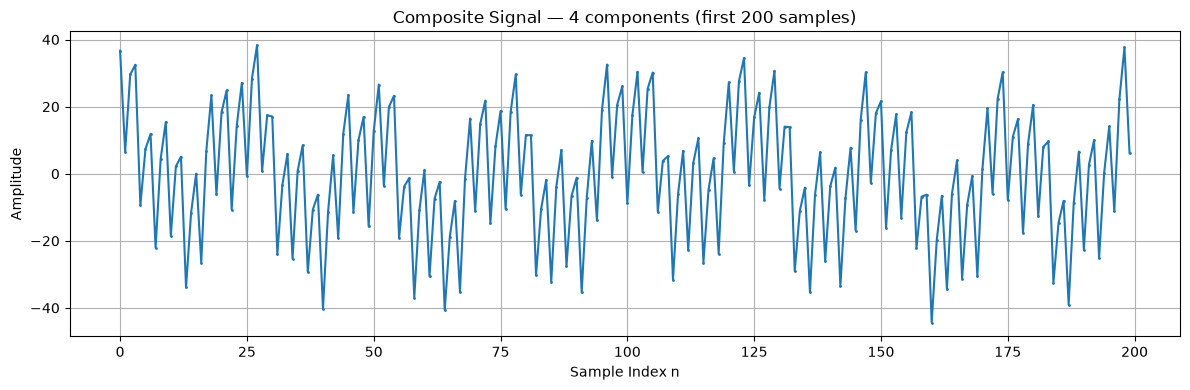

DFT completed in 12.15 seconds  (N = 3000)


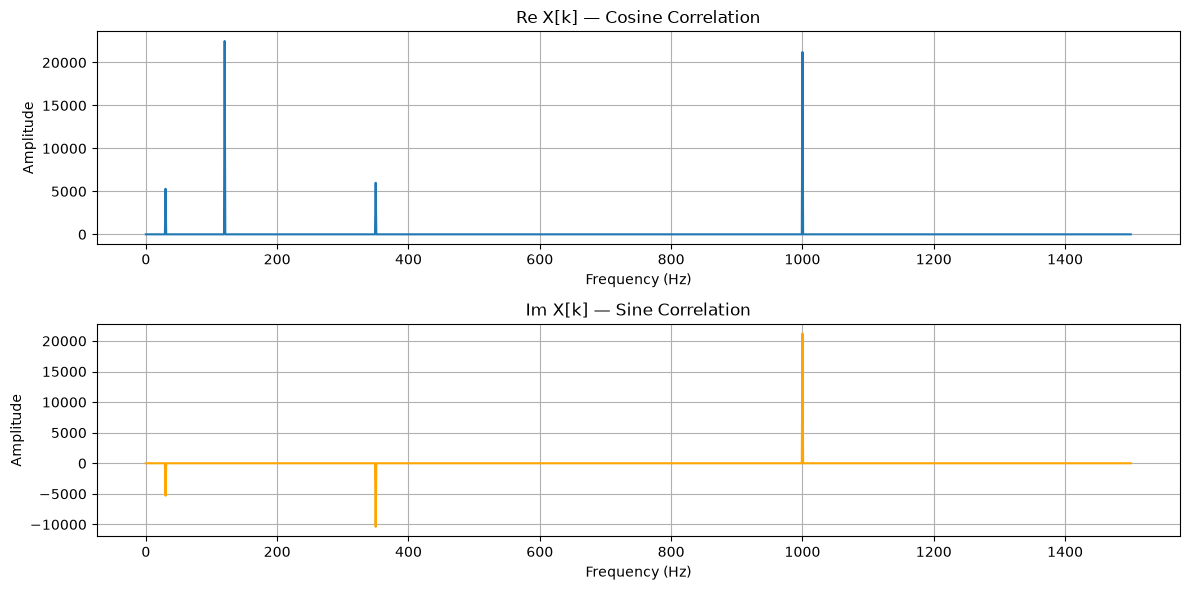

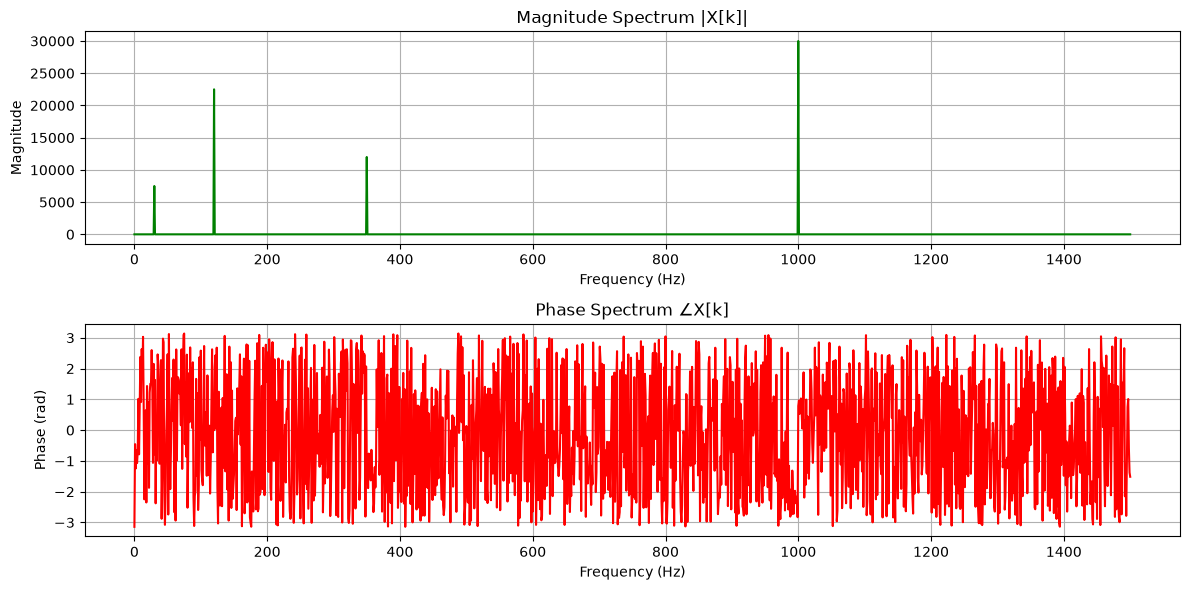


Detected frequency components (peak magnitude):
     30 Hz  ->  Mag =    7500.00,  Phase = -0.7854 rad
    120 Hz  ->  Mag =   22500.00,  Phase = +0.0000 rad
    350 Hz  ->  Mag =   12000.00,  Phase = -1.0472 rad
   1000 Hz  ->  Mag =   30000.00,  Phase = +0.7854 rad

Original amplitudes : [np.int64(5), np.int64(15), np.int64(8), np.int64(20)]
Original phases (rad): ['0.7854', '1.5708', '0.5236', '2.3562']


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import time

frequencies = np.array([30, 120, 350, 1000])   # Hz
amplitudes  = np.array([5, 15, 8, 20])          # arbitrary units
phases      = np.array([np.pi/4, np.pi/2, np.pi/6, 3*np.pi/4])  # radians

# Sampling parameters
f_max = np.max(frequencies) # 1000 Hz
Fs = 3 * f_max # 3000 Hz — well above the Nyquist rate of 2*f_max = 2000 Hz.
# The Nyquist-Shannon theorem guarantees that sampling at Fs > 2*f_max
# perfectly reconstructs the original continuous signal with no aliasing.

N = Fs # 1 second of data → N = 3000 samples
n = np.arange(N) # sample indices 0, 1, …, N-1
t = n / Fs  # corresponding time instants (seconds)

# BUILD THE COMPOSITE SIGNAL
# Each sinusoidal component is A_i * sin(2*pi*f_i*t + phi_i).
# The Fourier Transform works on this composite signal x[n].
x = np.zeros(N)
for i in range(len(frequencies)):
    x += amplitudes[i] * np.sin(2 * np.pi * frequencies[i] * t + phases[i])

# Plot the time-domain signal (first 200 samples for clarity)
plt.figure(figsize=(12, 4))
plt.plot(n[:200], x[:200], marker='.', markersize=2)
plt.title(f'Composite Signal — {len(frequencies)} components (first 200 samples)')
plt.xlabel('Sample Index n')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.show()

"""
DISCRETE FOURIER TRANSFORM
The DFT converts the time-domain signal x[n] into its frequency-
domain representation X[k]. For each frequency bin k, it computes:

#   Re X[k] =  Σ  x[i] · cos(2π·k·i / N)   (cosine correlation)
#              i

#   Im X[k] = −Σ  x[i] · sin(2π·k·i / N)   (sine correlation)
#              i
Intuition: at the "correct" frequency bin, the sine/cosine basis
functions line up with the signal, so their products add up
constructively → large Re/Im values. At wrong frequencies, the
products oscillate and cancel out → values near zero.
"""
K = N // 2 + 1# number of unique bins (real signal → symmetric)
Re_X = np.zeros(K)
Im_X = np.zeros(K)

start = time.time()
for k in range(K):
    sum_re = 0.0
    sum_im = 0.0
    for i in range(N):
        angle = 2 * np.pi * k * i / N
        # Multiply the signal sample by the cosine basis function
        # and accumulate → gives the real (cosine) component of X[k]
        sum_re += x[i] * np.cos(angle)
        # Multiply by the sine basis function and accumulate → gives
        # the imaginary (sine) component of X[k] (note the minus sign
        # in the DFT definition, applied below)
        sum_im += x[i] * np.sin(angle)
    Re_X[k] = sum_re
    Im_X[k] = -sum_im   # negative sign per the DFT convention

elapsed = time.time() - start
print(f'DFT completed in {elapsed:.2f} seconds  (N = {N})')

# FREQUENCY AXIS
# Each bin index k maps to a physical frequency of k * Fs / N Hz.
freq_axis = np.arange(K) * Fs / N

# Plot Re X[k] and Im X[k]
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))
ax1.plot(freq_axis, Re_X)
ax1.set_title('Re X[k] — Cosine Correlation')
ax1.set_xlabel('Frequency (Hz)')
ax1.set_ylabel('Amplitude')
ax1.grid(True)
ax2.plot(freq_axis, Im_X, color='orange')
ax2.set_title('Im X[k] — Sine Correlation')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Amplitude')
ax2.grid(True)
plt.tight_layout()
plt.show()

# MAGNITUDE AND PHASE SPECTRA
# Magnitude: how strong each frequency component is.
#   Mag X[k] = sqrt( Re X[k]^2 + Im X[k]^2 )

# Phase: the angular offset of each sinusoidal component.
#   Phase X[k] = arctan2( Im X[k], Re X[k] )
Mag_X   = np.sqrt(Re_X**2 + Im_X**2)
Phase_X = np.arctan2(Im_X, Re_X)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))
ax1.plot(freq_axis, Mag_X, color='green')
ax1.set_title('Magnitude Spectrum |X[k]|')
ax1.set_xlabel('Frequency (Hz)')
ax1.set_ylabel('Magnitude')
ax1.grid(True)
ax2.plot(freq_axis, Phase_X, color='red')
ax2.set_title('Phase Spectrum ∠X[k]')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Phase (rad)')
ax2.grid(True)
plt.tight_layout()
plt.show()

# VERIFY DETECTED COMPONENTS AGAINST THE ORIGINALS
# We look up the magnitude and phase at exactly the bin index
# corresponding to each planted frequency and compare.

print('\nDetected frequency components (peak magnitude):')
for i in range(len(frequencies)):
    k = int(frequencies[i] * N / Fs)          # bin index for this frequency
    print(f'  {frequencies[i]:>5d} Hz  ->  Mag = {Mag_X[k]:>10.2f},  '
          f'Phase = {Phase_X[k]:>+.4f} rad')

print(f'\nOriginal amplitudes : {list(amplitudes)}')
print(f'Original phases (rad): {[f"{p:.4f}" for p in phases]}')

### Observations

- The magnitude spectrum shows four distinct peaks at exactly 30, 120, 350, and 1000 Hz — the frequencies we planted. Everywhere else the magnitude is essentially zero, confirming that the DFT correctly isolates each component.
- The phase spectrum reports the angular offset at each detected frequency, matching the original phase values.
- Compared to the 6-component signal in the procedure, this 4-component signal is simpler and the DFT finishes faster because N is smaller (3000 vs 5000). The core mechanism is as follows: correlate the signal with every possible sinusoidal basis function, then read off the strength (magnitude) and timing (phase) of each match.

## 10. Artificial Intelligence (AI) Use Disclosure Statement

I hereby declare that artificial intelligence (AI) tools were used, if applicable, in the preparation of this academic
work. The following indicates the nature and extent of AI assistance:

**Tools Used**: Github Copilot, Opencode, Claude

**Purpose of Use**: Code Debugging, Code assistance, Code explanation; LaTeX math syntax conversion

**Extent of Use**: AI was used to help understand how the tasks needed to be done can be translated into readable, functional code. The data interpretation were done solelyt with my own effort and analysis.

***
By submitting this activity, I affirm that my use of AI complies with T.I.P.'s AI usage policy and does not exceed the
permitted limits for similarity, automated content generation, or academic assistance.

I understand that any false, incomplete, or misleading disclosure may be subject to investigation in accordance
with due process and may result in sanctions for violation of existing T.I.P. policies.